# Notebook 3 - The Watchlist 

This notebook turns the XGBoost out-of-fold probabilities into one of the project's  deliverables: a ranked watchlist of undesignated planning areas that most resemble Milieuschutz-designated ones. 

Working from the out-of-fold scores keeps every ranking honest, since each area was scored by a model that never saw its own district. After restricting to undesignated areas (y_true = 0), the distribution of scores is inspected to place a pragmatic cutoff, and the resulting shortlist is cross-checked against milieu_anteil, the continuous protected share, kept strictly out of the model as a feature and used here only to separate genuinely unprotected candidates from areas where some Milieuschutz already exists. 

The shortlist is then mapped across Berlin as an interpretive urgency layer (model similarity weighted by how little protection is already in place), and exported for the Cleanlab label-quality check in NB4 and for the dashboard. 

As throughout Module 2, the score expresses similarity to the existing designation pattern, not an objective probability of displacement. The undesignated areas surfacing near the top are precisely the early-warning candidates the platform is built to find.


In [19]:
#load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [20]:
#load the XGBoost OOF probabilities set 
xgb_oof = pd.read_csv("../../models/M_oof_xgboost.csv", dtype={"plr_id": str})

#load dataset_0 for readable identifiers (plr_name, bez)
meta = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
meta = meta[["plr_id", "plr_name", "bez"]]

#zero-pad plr_id consistently (same convention as NB1/NB2)
for d in (xgb_oof, meta):   
    d["plr_id"] = d["plr_id"].astype(str).str.zfill(8)

#build the working table: XGBoost oof_prob + labels + names/district
df = xgb_oof.merge(meta, on="plr_id", how="left")

#sanity 
assert df["plr_name"].notna().all(), "some PLR did not get a name/Bezirk — check the merge"
assert len(df) == len(xgb_oof), "merge changed row count — duplicate plr_id?"
print(f"{len(df)} PLR | {int(df['y_true'].sum())} designated | "
      f"{int((df['y_true']==0).sum())} undesignated")

527 PLR | 109 designated | 418 undesignated


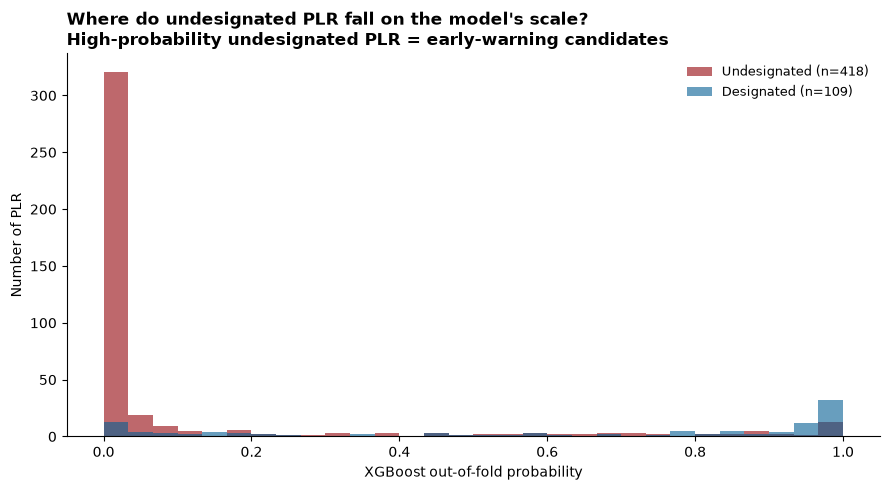

      plr_id                plr_name                              bez  oof_prob
0   01401044              Uferstraße                       01 - Mitte  0.999109
1   01300731           Koloniestraße                       01 - Mitte  0.997601
2   01100416             Arkonaplatz                       01 - Mitte  0.995976
3   07100206      Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505
4   01200623             Stephankiez                       01 - Mitte  0.986148
5   01401049             Schulstraße                       01 - Mitte  0.985959
6   04501147       Leon-Jessel-Platz  04 - Charlottenburg-Wilmersdorf  0.984600
7   01300836   Humboldthain Nordwest                       01 - Mitte  0.984006
8   01200522      Elberfelder Straße                       01 - Mitte  0.983263
9   01200628       Lüneburger Straße                       01 - Mitte  0.979387
10  09200511       Griechischer Park            09 - Treptow-Köpenick  0.977478
11  01300834           Brunnenstraße    

In [21]:
#Distribution of XGBoost oof_prob, split by actual designation status
#Goal: where do undesignated PLR sit? Is there a natural cutoff for the watchlist that can be used?
desig   = df.loc[df["y_true"] == 1, "oof_prob"]
undesig = df.loc[df["y_true"] == 0, "oof_prob"]

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 1, 31)
ax.hist(undesig, bins=bins, alpha=0.6, color="#94030B", label=f"Undesignated (n={len(undesig)})")
ax.hist(desig,   bins=bins, alpha=0.6, color="#035E93", label=f"Designated (n={len(desig)})")
ax.set_xlabel("XGBoost out-of-fold probability", fontsize=10)
ax.set_ylabel("Number of PLR", fontsize=10)
ax.set_title("Where do undesignated PLR fall on the model's scale?\n"
             "High-probability undesignated PLR = early-warning candidates",
             fontsize=12, fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

#eyeball the top undesignated PLR to see where probabilities start dropping
top_undesig = (df[df["y_true"] == 0]
               .sort_values("oof_prob", ascending=False)
               [["plr_id", "plr_name", "bez", "oof_prob"]]
               .head(30)
               .reset_index(drop=True))
print(top_undesig.to_string())

In [22]:
#Watchlist: undesignated PLR the model ranks most designation-like
#Cutoff N=25, chosen at the visible probability drop (~0.82 -> 0.77 after rank 24)

N_WATCHLIST = 25

watchlist = (
    df[df["y_true"] == 0]
    .sort_values("oof_prob", ascending=False)
    .head(N_WATCHLIST)
    .reset_index(drop=True)
    [["plr_id", "plr_name", "bez", "oof_prob"]]
)
watchlist.index = watchlist.index + 1         
watchlist.index.name = "rank"

#document the cutoff: what prob does the last included PLR have, and the first excluded?
cutoff_in  = watchlist["oof_prob"].iloc[-1]
first_out  = (df[df["y_true"] == 0]
              .sort_values("oof_prob", ascending=False)
              ["oof_prob"].iloc[N_WATCHLIST])
print(f"Watchlist: {N_WATCHLIST} undesignated PLR")
print(f"Cutoff: last included oof_prob = {cutoff_in:.3f} | first excluded = {first_out:.3f}")
print(f"Bezirk distribution:\n{watchlist['bez'].value_counts().to_string()}")
print()
print(watchlist.to_string())

Watchlist: 25 undesignated PLR
Cutoff: last included oof_prob = 0.824 | first excluded = 0.767
Bezirk distribution:
bez
01 - Mitte                         12
04 - Charlottenburg-Wilmersdorf     4
07 - Tempelhof-Schöneberg           3
09 - Treptow-Köpenick               2
02 - Friedrichshain-Kreuzberg       1
03 - Pankow                         1
08 - Neukölln                       1
12 - Reinickendorf                  1

        plr_id                plr_name                              bez  oof_prob
rank                                                                             
1     01401044              Uferstraße                       01 - Mitte  0.999109
2     01300731           Koloniestraße                       01 - Mitte  0.997601
3     01100416             Arkonaplatz                       01 - Mitte  0.995976
4     07100206      Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505
5     01200623             Stephankiez                       01 - Mitte  0.986148
6

In [23]:
#going further we check: among areas the model flags, where is the early-warning value highest?
#bring in milieu_anteil and 1-milieu_anteil to create an urgency variable (below)
#NB model was trained on binary milieuschutz >50%, the watchlist is now using the continuos milieu_anteil
#variable has 0 NaNs, verified at target-variable build; anteil = 0 = observed "no protection"

labels_full = pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})
labels_full["plr_id"] = labels_full["plr_id"].astype(str).str.zfill(8)

#pull milieu_anteil onto the watchlist
watchlist_checked = watchlist.merge(
    labels_full[["plr_id", "milieu_anteil"]], on="plr_id", how="left"
)
watchlist_checked.index = watchlist_checked.index + 1
watchlist_checked.index.name = "rank"


print(watchlist_checked[["plr_name", "bez", "oof_prob", "milieu_anteil"]].to_string())

                    plr_name                              bez  oof_prob  milieu_anteil
rank                                                                                  
1                 Uferstraße                       01 - Mitte  0.999109       0.487524
2              Koloniestraße                       01 - Mitte  0.997601       0.221120
3                Arkonaplatz                       01 - Mitte  0.995976       0.000959
4         Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505       0.495631
5                Stephankiez                       01 - Mitte  0.986148       0.383226
6                Schulstraße                       01 - Mitte  0.985959       0.238271
7          Leon-Jessel-Platz  04 - Charlottenburg-Wilmersdorf  0.984600       0.000000
8      Humboldthain Nordwest                       01 - Mitte  0.984006       0.129641
9         Elberfelder Straße                       01 - Mitte  0.983263       0.000026
10         Lüneburger Straße               

here we see that some of the very high lookalikes are nearly protected, this is why we create a variable that states clearly whether they are protected, partially protected or not. 

In [24]:
#Refine: milieu_anteil > 0 is too coarse. Split by how much protection already exists
def classify(a):
    if a < 0.10:
        return "effectively unprotected"      # early-warning candidate
    elif a < 0.40:
        return "partially protected"          # protection started, substantial gap
    else:
        return "near-designated"              # just below the 50% majority threshold

watchlist_checked["status"] = watchlist_checked["milieu_anteil"].apply(classify)
print(watchlist_checked["status"].value_counts().to_string(), "\n")
print(watchlist_checked[["plr_name", "bez", "oof_prob", "milieu_anteil", "status"]].to_string())

status
partially protected        10
effectively unprotected    10
near-designated             5 

                    plr_name                              bez  oof_prob  milieu_anteil                   status
rank                                                                                                           
1                 Uferstraße                       01 - Mitte  0.999109       0.487524          near-designated
2              Koloniestraße                       01 - Mitte  0.997601       0.221120      partially protected
3                Arkonaplatz                       01 - Mitte  0.995976       0.000959  effectively unprotected
4         Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505       0.495631          near-designated
5                Stephankiez                       01 - Mitte  0.986148       0.383226      partially protected
6                Schulstraße                       01 - Mitte  0.985959       0.238271      partially protected
7    

In [25]:
gdf = gpd.read_file("../../data/real_estate/Geodata/PLR_raw.geojson")
gdf["plr_id"] = gdf["plr_id"].astype(str).str.zfill(8)

print("Spalten:", gdf.columns.tolist())
print("CRS:", gdf.crs)
print("Zeilen:", len(gdf))
print(gdf.drop(columns="geometry").head(3).to_string())

Spalten: ['id', 'plr_id', 'plr_name', 'bzr_id', 'bzr_name', 'pgr_id', 'pgr_name', 'bez', 'finhalt', 'stadtraum_id', 'stadtraum_name', 'stand', 'geometry']
CRS: EPSG:25833
Zeilen: 542
                        id    plr_id           plr_name  bzr_id        bzr_name pgr_id pgr_name         bez       finhalt stadtraum_id stadtraum_name       stand
0  a_lor_plr_2021.01100101  01100101       Stülerstraße  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  3.669331e+05            1   Innere Stadt  01.01.2021
1  a_lor_plr_2021.01100102  01100102  Großer Tiergarten  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  3.919852e+06            1   Innere Stadt  01.12.2021
2  a_lor_plr_2021.01100103  01100103       Lützowstraße  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  5.471832e+05            1   Innere Stadt  01.12.2021


In [26]:
#Merge model output onto PLR geometries; milieu_anteil pulled in SEPARATELY (interpretation only, never a feature)

#labels_full holds milieu_anteil (from target_milieuschutz.csv) — kept out of df on purpose
plot_geo1 = (
    gdf
    .merge(df[["plr_id", "oof_prob", "y_true"]], on="plr_id", how="left")
    .merge(labels_full[["plr_id", "milieu_anteil"]], on="plr_id", how="left")
)

#Plot 1: Plot watchlist for all with protected areas <50%
undes1 = (plot_geo1["y_true"] == 0)
plot_geo1["watchlist"] = np.nan
plot_geo1.loc[undes1, "watchlist"] = (
    plot_geo1.loc[undes1, "oof_prob"])


#diagnostics: how many geometries got no model row (the ~15 dropped PLR)?
n_nomatch1 = plot_geo1["oof_prob"].isna().sum()
print(f"{len(plot_geo1)} geometries | {n_nomatch1} without a model row (dropped/uninhabited PLR)")


542 geometries | 15 without a model row (dropped/uninhabited PLR)


In [27]:
#labels_full holds milieu_anteil (from target_milieuschutz.csv) — kept out of df on purpose
plot_geo2 = (
    gdf
    .merge(df[["plr_id", "oof_prob", "y_true"]], on="plr_id", how="left")
    .merge(labels_full[["plr_id", "milieu_anteil"]], on="plr_id", how="left")
)

#Plot 2: urgency only for UNDESIGNATED PLR; designated + non-modelled stay NaN (grey)
undes2 = (plot_geo2["y_true"] == 0)
plot_geo2["urgency"] = np.nan
plot_geo2.loc[undes2, "urgency"] = (
    plot_geo2.loc[undes2, "oof_prob"] * (1 - plot_geo2.loc[undes2, "milieu_anteil"])
)

#diagnostics: how many geometries got no model row (the ~15 dropped PLR)?
n_nomatch2 = plot_geo2["oof_prob"].isna().sum()
print(f"{len(plot_geo2)} geometries | {n_nomatch2} without a model row (dropped/uninhabited PLR)")
print(f"urgency range: {plot_geo2['urgency'].min():.3f} – {plot_geo2['urgency'].max():.3f}")

542 geometries | 15 without a model row (dropped/uninhabited PLR)
urgency range: 0.000 – 0.995


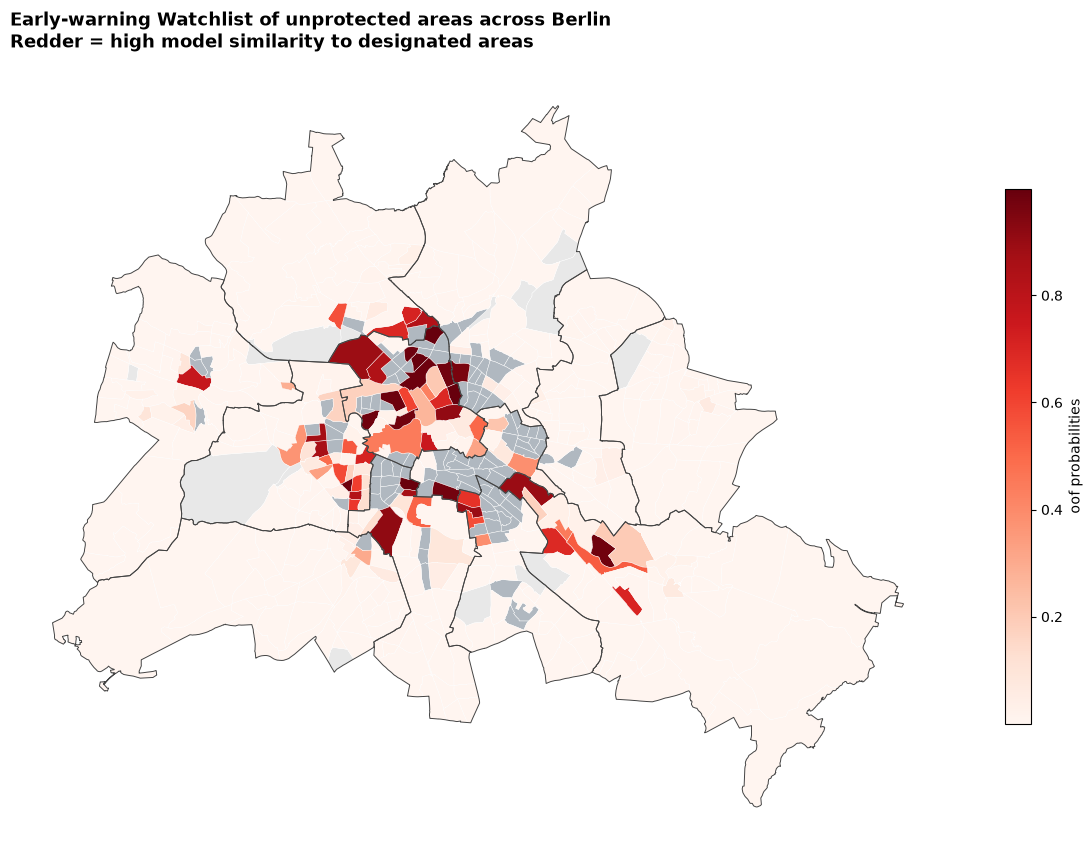

In [28]:
#plot1 the watchlist
#which undesignated PLR most resemble designated ones


fig, ax = plt.subplots(figsize=(12, 11))

#layer 1: all PLR as light grey base (so dropped + designated areas are visible, not holes)
plot_geo1.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.3)

#layer 2: designated PLR in a distinct neutral (already protected — not "urgent")
plot_geo1[plot_geo1["y_true"] == 1].plot(
    ax=ax, color="#b0b8c0", edgecolor="white", linewidth=0.3
)

#layer 3: undesignated PLR coloured by urgency (white -> red)
plot_geo1[undes1].plot(
    ax=ax, cmap="Reds", edgecolor="white", linewidth=0.3,
    legend=True, column="oof_prob", legend_kwds={"label": "oof probabilities",
                              "shrink": 0.5}
)

#Bezirk outlines so the weak-fold districts are locatable
gdf.dissolve("bez").boundary.plot(ax=ax, color="#444444", linewidth=0.7)

ax.set_title("Early-warning Watchlist of unprotected areas across Berlin\n"
             "Redder = high model similarity to designated areas",
             fontsize=13, fontweight="bold", loc="left")
ax.axis("off")
plt.tight_layout()
plt.savefig("../../plots/resemblance_map.png", dpi=200, bbox_inches="tight")
plt.show()

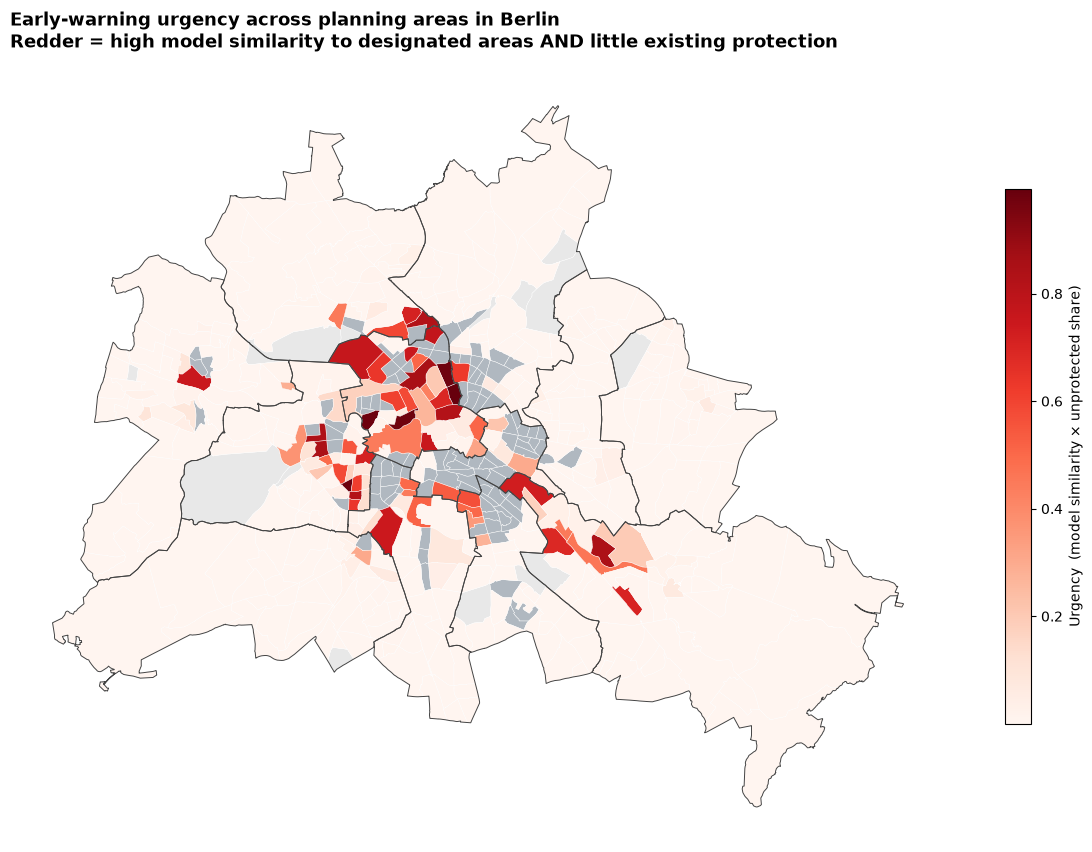

In [29]:
#plot2: urgency as model similarity x unprotected share 
#where is the early-warning value highest" — high similarity and little existing protection
fig, ax = plt.subplots(figsize=(12, 11))

#layer 1: all PLR as light grey base (so dropped + designated areas are visible, not holes)
plot_geo2.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.3)

#layer 2: designated PLR in a distinct neutral (already protected — not "urgent")
plot_geo2[plot_geo2["y_true"] == 1].plot(
    ax=ax, color="#b0b8c0", edgecolor="white", linewidth=0.3
)

#layer 3: undesignated PLR coloured by urgency (white -> red)
plot_geo2[undes2].plot(
    ax=ax, column="urgency", cmap="Reds", edgecolor="white", linewidth=0.3,
    legend=True, legend_kwds={"label": "Urgency  (model similarity × unprotected share)",
                              "shrink": 0.5}
)

#Bezirk outlines so the weak-fold districts are locatable
gdf.dissolve("bez").boundary.plot(ax=ax, color="#444444", linewidth=0.7)

ax.set_title("Early-warning urgency across planning areas in Berlin\n"
             "Redder = high model similarity to designated areas AND little existing protection",
             fontsize=13, fontweight="bold", loc="left")
ax.axis("off")
plt.tight_layout()
plt.savefig("../../plots/urgency_watchlist.png", dpi=200, bbox_inches="tight")
plt.show()

In [30]:
#how are the two watchlists differing? 

sub = plot_geo2[undes2].copy()
sub["rank_prob"] = sub["oof_prob"].rank(ascending=False)
sub["rank_urg"]  = sub["urgency"].rank(ascending=False)

wl = sub.nsmallest(25, "rank_prob")          # the actual watchlist
print(wl[["oof_prob", "milieu_anteil", "urgency"]]
      .assign(shift=wl["rank_prob"] - wl["rank_urg"])
      .sort_values("shift", key=abs, ascending=False)
      .head(10))

# does urgency pull anyone INTO the top 25 who wasn't there by oof_prob?
in_prob = set(sub.nsmallest(25, "rank_prob").index)
in_urg  = set(sub.nsmallest(25, "rank_urg").index)
print("only in oof top25:", in_prob - in_urg)
print("only in urgency top25:", in_urg - in_prob)

     oof_prob  milieu_anteil   urgency  shift
43   0.999109       0.487524  0.512020  -36.0
292  0.992505       0.495631  0.500588  -36.0
22   0.986148       0.383226  0.608231  -24.0
300  0.871418       0.484008  0.449644  -24.0
59   0.975650       0.453041  0.533641  -22.0
336  0.893927       0.434770  0.505274  -21.0
160  0.862824       0.018465  0.846893   15.0
194  0.823657       0.000000  0.823657   14.0
507  0.824959       0.000000  0.824959   14.0
126  0.963523       0.348877  0.627372  -13.0
only in oof top25: {292, 43, 300, 336, 22, 59, 126}
only in urgency top25: {384, 4, 396, 14, 213, 186, 508}


7 PLRs switch sides, which ones come in in the urgency watchlist? Do they also come from the weak fold (Charlottenburg-Wilmersdorf and Lichtenberg)? 

In [31]:
#build sub FIRST
sub = plot_geo2[undes2].copy()

#strip the "NN - " prefix
sub["bez_name"] = sub["bez"].str.split(" - ").str[-1].str.strip()

#define what counts as weak fold
weak_fold_names = ["Charlottenburg-Wilmersdorf", "Lichtenberg"]

#pick the entrants and include bez_name in the columns
entrants = [384, 4, 396, 14, 213, 186, 508]
cols = ["bez", "bez_name", "oof_prob", "milieu_anteil", "urgency"]
entrant_rows = sub.loc[entrants, cols].copy()

#match on bez_name (stripped), NOT bez (prefixed)
entrant_rows["weak_fold"] = entrant_rows["bez_name"].isin(weak_fold_names)

entrant_rows = entrant_rows.sort_values("oof_prob", ascending=False)
print(entrant_rows)
print(f"\n{entrant_rows['weak_fold'].sum()} of {len(entrant_rows)} entrants sit in the weak fold")

                                 bez                    bez_name  oof_prob  \
213                     05 - Spandau                     Spandau  0.766517   
4                         01 - Mitte                       Mitte  0.756666   
186  04 - Charlottenburg-Wilmersdorf  Charlottenburg-Wilmersdorf  0.712941   
508               12 - Reinickendorf               Reinickendorf  0.712730   
396            09 - Treptow-Köpenick            Treptow-Köpenick  0.704122   
14                        01 - Mitte                       Mitte  0.693884   
384            09 - Treptow-Köpenick            Treptow-Köpenick  0.689616   

     milieu_anteil   urgency  weak_fold  
213   1.801573e-02  0.752708      False  
4     2.602949e-08  0.756666      False  
186   5.816938e-09  0.712941       True  
508   0.000000e+00  0.712730      False  
396   0.000000e+00  0.704122      False  
14    0.000000e+00  0.693884      False  
384   0.000000e+00  0.689616      False  

1 of 7 entrants sit in the weak fold


### TEAM DISCUSSION 

the updated watchlist entails one PLR from a weak fold which is to be ignored. However, the out of fold probabilities go down until 68% 

### missing still:

PROBLEM: 
Die Watchlist rankt nach oof_prob, aber deine Karte färbt nach urgency — und die Tabelle zeigt schwarz auf weiß, wie stark die zwei auseinanderlaufen. Schau dir Rang 1 an: Uferstraße, oof_prob = 0.999 (Listen-Spitze!), aber milieu_anteil = 0.49. Die urgency ist also 0.999 × (1 − 0.49) ≈ 0.51 — nur mittelrot auf der Karte. Rang 4 (Großgörschenstraße, anteil 0.50) fällt sogar auf ~0.50 urgency. Dagegen Rang 3 (Arkonaplatz, anteil ≈ 0) bleibt bei ~0.996 urgency — dunkelrot. Der Listen-Erste ist auf der Karte blass, ein weiter unten Stehender leuchtet. Genau die Inkonsistenz, die du in Cell 10 als Teamdiskussion vermerkt hast — hier ist der konkrete Beleg.


Die roten Cluster liegen fast alle innerstädtisch, direkt neben den grauen (bereits geschützten) Flächen — Kreuzberg, Neukölln, Friedrichshain, der Streifen nach Südosten. 

Das ist inhaltlich genau, was die Frühwarn-These erwartet: Die Kandidaten sitzen im Ring um die schon geschützten Gebiete, nicht zufällig am Stadtrand. Das ist ein starkes Sanity-Signal, dass die Karte plausibel ist — dokumentier das ruhig in der Karten-Diskussion.

- NAs and already designated stärker auseinander 
- Und der Notebook-Satz zur konstruierten Größe ist hier besonders wichtig, weil die Karte so überzeugend aussieht, dass man urgency für einen Modell-Output halten könnte: „urgency is a derived interpretive score (model similarity × unprotected share), not a direct model prediction; grey = already designated or not modelled."


In [33]:
#Export the watchlist for NB4 Cleanlab validation + dashboard
#Both rankings are taken side by side: membership = oof_prob top-25 * urgency top-25
#so neither ranking has gaps. rank_* is NaN when a PLR isn't in that top-25.

N_WATCHLIST = 25

#full undesignated set with both scores (from plot_geo2, which has urgency)
und = plot_geo2[undes2].copy()
und["urgency"] = und["oof_prob"] * (1 - und["milieu_anteil"])   

#rank both ways (1 = most designation-like / most urgent)
und["rank_oof"] = und["oof_prob"].rank(ascending=False, method="min").astype(int)
und["rank_urgency"] = und["urgency"].rank(ascending=False, method="min").astype(int)

#membership = union of the two top-25s
in_oof = und["rank_oof"] <= N_WATCHLIST
in_urg = und["rank_urgency"] <= N_WATCHLIST
watchlist_out = und[in_oof | in_urg].copy()

#blank out ranks outside each top-25 so "rank" always means "rank within the top-25"
watchlist_out.loc[~in_oof, "rank_oof"] = pd.NA
watchlist_out.loc[~in_urg, "rank_urgency"] = pd.NA

#descriptive status tag (three-way classify), attached from milieu_anteil
def classify(a):
    if a < 0.10:
        return "effectively unprotected"
    elif a < 0.40:
        return "partially protected"
    else:
        return "near-designated"
watchlist_out["status"] = watchlist_out["milieu_anteil"].apply(classify)

#a flag so readers can see at a glance which list a PLR owes its place to
watchlist_out["in_oof_top25"] = in_oof[in_oof | in_urg].values
watchlist_out["in_urgency_top25"] = in_urg[in_oof | in_urg].values

#order the file by urgency (headline), oof_prob as tiebreak; keep both rank cols
watchlist_out = (
    watchlist_out
    .sort_values(["rank_urgency", "rank_oof"], na_position="last")
    [["plr_id", "plr_name", "bez", "oof_prob", "urgency",
      "milieu_anteil", "status", "rank_oof", "rank_urgency",
      "in_oof_top25", "in_urgency_top25"]]
    .reset_index(drop=True)
)

watchlist_out.to_csv("../../models/M2_watchlist.csv", index=False)
print(f"exported {len(watchlist_out)} PLR "
      f"(union of oof_prob top-{N_WATCHLIST} and urgency top-{N_WATCHLIST}) -> M_watchlist.csv")
print(watchlist_out.to_string(index=False))

exported 32 PLR (union of oof_prob top-25 and urgency top-25) -> M_watchlist.csv
  plr_id               plr_name                             bez  oof_prob  urgency  milieu_anteil                  status  rank_oof  rank_urgency  in_oof_top25  in_urgency_top25
01100416            Arkonaplatz                      01 - Mitte  0.995976 0.995020   9.594333e-04 effectively unprotected       3.0           1.0          True              True
04501147      Leon-Jessel-Platz 04 - Charlottenburg-Wilmersdorf  0.984600 0.984600   0.000000e+00 effectively unprotected       7.0           2.0          True              True
01200522     Elberfelder Straße                      01 - Mitte  0.983263 0.983237   2.635215e-05 effectively unprotected       9.0           3.0          True              True
01200628      Lüneburger Straße                      01 - Mitte  0.979387 0.979387   0.000000e+00 effectively unprotected      10.0           4.0          True              True
01300834          Brunnenstra